# Lag-Rank Analysis

> Compute temporal factor scores by ranking each transition's absolute lag among all available lags.

The temporal factor score [@polyn2009context] measures temporal organization in free recall by computing,
for each transition, the percentile rank of the actual absolute lag among all available absolute lags.
A score of 0.5 indicates chance; scores above 0.5 reflect a temporal contiguity effect.

Unlike raw lag-CRP curves, the temporal factor condenses temporal organization into a single
per-subject scalar that can be tested against chance with a one-sample t-test.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `trial_query` | Query selecting trials to analyze |
| `size` | Max study positions an item can occupy |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.lagrank import (
    lagrank,
    percentile_rank,
    plot_lagrank,
    subject_lagrank,
    test_lagrank,
    LagRankTestResult,
    LagRankComparisonResult,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
trial_query = "data['listLength'] > 0"
size = 1

In [4]:
#| code-summary: Load data
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

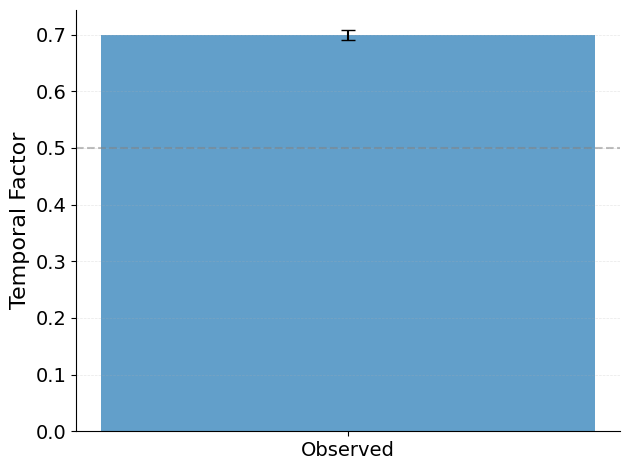

In [5]:
#| code-summary: Plot lag-rank temporal factor
#| label: fig-lagrank
#| fig-cap: "Temporal factor score. Dashed line indicates chance (0.5)."
plot_lagrank(data, trial_mask, labels=["Observed"], size=size)
save_figure(figure_dir, figure_str)

## Statistical Tests

In [6]:
#| code-summary: Test temporal factor against chance
factors = subject_lagrank(data, trial_mask, size=size)
result = test_lagrank(factors)

print()
print("=" * 60)
print("Temporal Factor: One-Sample Test")
print("=" * 60)
print("H0: The temporal factor equals 0.5 (chance).")
print(result)


Temporal Factor: One-Sample Test
H0: The temporal factor equals 0.5 (chance).
N=126
Mean factor: 0.6989
t-stat: 45.351 p=0.0000
W-stat: 0.0 p=0.0000


---

## Reference

In [7]:
#| echo: false
show_doc(plot_lagrank)

---

### plot_lagrank

>      plot_lagrank (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr
>                    .typing.RecallDataset], trial_masks:Union[Sequence[jaxtypin
>                    g.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial_co
>                    unt']], color_cycle:Optional[list[str]]=None,
>                    labels:Optional[Sequence[str]]=None,
>                    contrast_name:Optional[str]=None,
>                    axis:Optional[matplotlib.axes._axes.Axes]=None, size:int=3,
>                    confidence_level:float=0.95)

*Plot subject-wise lag-rank factors as a bar chart.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each bar. |
| labels | Optional | None | Labels for each bar. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the lag-rank bar chart.** |

In [8]:
#| echo: false
show_doc(lagrank)

---

### lagrank

>      lagrank (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Compute per-trial lag-rank factors with support for repeated items.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'trials']** |  | **Per-trial temporal factor scores.** |

In [9]:
#| echo: false
show_doc(subject_lagrank)

---

### subject_lagrank

>      subject_lagrank (dataset:jaxcmr.typing.RecallDataset,
>                       trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                       size:int=3)

*Compute per-subject mean lag-rank factor.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **ndarray** |  | **Per-subject mean temporal factor, shape ``(n_subjects,)``.** |

In [10]:
#| echo: false
show_doc(percentile_rank)

---

### percentile_rank

>      percentile_rank (target:jaxtyping.Integer[Array,''],
>                       pool:jaxtyping.Integer[Array,'candidates'])

*Compute midpoint percentile rank of *target* in *pool*.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| target | Integer[Array, ''] | Value to rank. |
| pool | Integer[Array, 'candidates'] | Candidate values; entries < 0 are treated as missing. |
| **Returns** | **Float** | **Rank in [0, 1] where 1.0 = smallest in pool, 0.0 = largest.<br>Returns NaN when fewer than 2 valid entries.** |

### Statistical test functions

In [11]:
#| echo: false
show_doc(test_lagrank)

---

### test_lagrank

>      test_lagrank (subject_factors:numpy.ndarray)

*Test whether lag-rank factors differ from chance (0.5).*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| subject_factors | ndarray | Per-subject mean temporal factors. |
| **Returns** | **LagRankTestResult** | **One-sample t-test and Wilcoxon results.** |

In [12]:
# Temporal factor should be significantly above chance for HealeyKahana2014
assert result.mean_factor > 0.5, "Temporal factor should exceed chance"
assert result.t_pval < 0.05, "Should be statistically significant"